In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error
from sklearn.neighbors import KNeighborsRegressor

In [54]:
house_data = pd.read_csv("../data/kc_house_data.csv")
house_data.head(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [55]:
house_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [56]:
house_data['price'].describe()

count    2.161300e+04
mean     5.400881e+05
std      3.671272e+05
min      7.500000e+04
25%      3.219500e+05
50%      4.500000e+05
75%      6.450000e+05
max      7.700000e+06
Name: price, dtype: float64

In [57]:
house_data['sqft_living'].describe()

count    21613.000000
mean      2079.899736
std        918.440897
min        290.000000
25%       1427.000000
50%       1910.000000
75%       2550.000000
max      13540.000000
Name: sqft_living, dtype: float64

1. Before building the model, start by looking at a scatterplot of price vs. the square footage of living space. What do you find? How strong does the relationship appear to be?

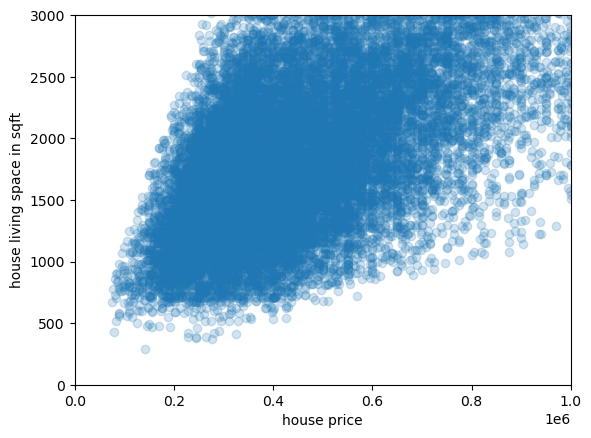

In [58]:
plt.scatter(house_data["price"], house_data["sqft_living"],alpha=0.2)
plt.xlim(0,1000000)
plt.ylim(0,3000)
plt.xlabel('house price')
plt.ylabel('house living space in sqft')
plt.show()

* The house price and living space in sqft are positively correlated. when the sqft increses the housing price also tend to increase but it also depends on various other factors.

2. Create a DataFrame, X, which contains one column, the sqft_living space and a Series, y, which contains the target variable.

One of the most important concepts when it comes to machine learning is that the only performance we care about is how well the model predicts on data that it has not seen yet.

One way to accomplish this is through setting aside a portion of the data as a **test set** and to train the model on the remaining portion.

In [59]:
X = house_data[['sqft_living']] #used 2 squered brackets to make sure the result in pandas data frame rather than a series
y= house_data['price']

#initialize the model
house_model = LinearRegression()
#train the model
house_model.fit(X, y)

print(X.describe())

3. Use the [train_test_split function](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) to create a training and a test set from X and y. Name the resulting pieces X_train, X_test, y_train, and y_test. When you do this, use 30% of the data in the test set. Also, use the random_state parameter so that we can compare model performance as we change the way we build our model.

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.3,train_size = 0.7 , random_state = 100)

4. Import the [LinearRegression class](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) from the linear_model module. Then create a linear regression instance and fit it to the training data.

In [67]:
ln_house_model = LinearRegression().fit(X_train,y_train)

In [68]:
ln_house_model.score(X,y)

0.4928373851268174

5. What is the intercept term, and what is the coefficient for sqft_living? How can you interpret how the model is using sqft_living to make predictions? Hint: You can get these values by looking at the .intercept_ and .coef_ attributes of the fit model.

In [69]:
ln_house_model.coef_

array([279.73039149])

In [70]:
ln_house_model.intercept_

np.float64(-40514.31944705092)

* The coefficient of a this model tells that when the additional 1 square foot of increase in living space the model predicts an avg  increase of 279.95945438 in the house price.
* Intercept represents predicted price of a house when the sqft is zero. While house with zero sqft is not possible, so the intercept act as a baseline and starting point for the regression line, helping to adjust the overall price level.

#the model is using sqft_living to make predictions
price = Intercept + (279.95945438) * (sqft_living)

In [12]:
#let's take sqft living is 1180 and check the house price
price1 = 1180 * 279.73039149 +(-40514.31944705092)
price1

289567.5425111491

In [13]:
#let's take sqft living is 770 and check the house price
price2 = 770 * 279.73039149 +(-40514.31944705092)
price2

174878.08200024907

The next step is to evaluate how well the model does on the unseen data. 

6. Use the predict method to generate a set of predictions on X_test. Save the results to y_pred. Question: What type of object is y_pred? What is its shape and how does it compare to y_test?

In [14]:
y_pred = ln_house_model.predict(X_test)

In [71]:
type(y_pred)

numpy.ndarray

In [72]:
y_pred.shape

(6484,)

In [73]:
y_test.shape

(6484,)

* y_pred is an 1D array with a length equal to number of samples in X_test.
* y_test contains the actual correct labels for test data, y_pred contains the model predictions. 


Now, we can evaluate how well the model did. There are a number of different metrics that could be used. Let's look at five of them, mean squared error, root mean squared error, mean absolute error, mean absolute percentage error, and R^2 score. For more information on these metrics, see https://developer.nvidia.com/blog/a-comprehensive-overview-of-regression-evaluation-metrics/.

7. Calculate each metric on the test set. For each one, interpret what the number means.

In [15]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse:.2f}, RMSE: {rmse}, MAE: {mae}, MAPE: {mape}, R2: {r2}")

MSE: 67101265833.11, RMSE: 259039.1202755027, MAE: 173004.81381428379, MAPE: 0.3615992706300183, R2: 0.5051638992504213


It's always a good idea to see how well your model performs against a simple baseline. In the case of regression, a very simple model would be one that just predicts the overall average home price on the training data.

In [16]:
# To create simple baseline importing dummyresgressor from scikitlearn
from sklearn.dummy import DummyRegressor

In [17]:
#intitialize the dummy regressor
baseline_model = DummyRegressor(strategy="mean") #using mean as baseline
#Fit it in the training data
baseline_model = baseline_model.fit(X_train,y_train)
#predict on the test data
y_baseline_pred = baseline_model.predict(X_test)
#Evaluate the baseline
baseline_rmse = root_mean_squared_error(y_test,y_baseline_pred)
print(f"Baseline RMSE: {baseline_rmse:.2f}")

Baseline RMSE: 368243.97


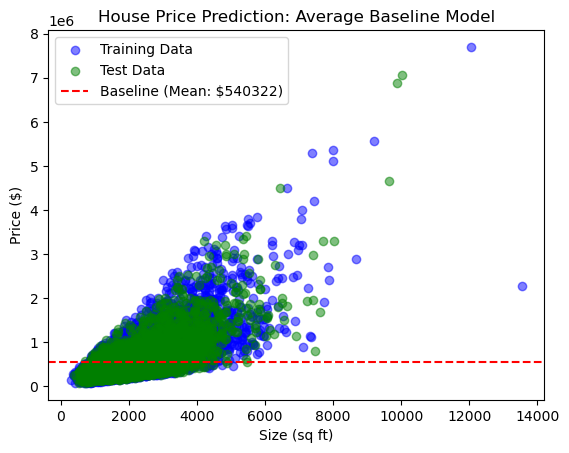

In [18]:
#Plot training data
plt.scatter(X_train,y_train, color='blue', alpha=0.5, label='Training Data')
#Plot testing data
plt.scatter(X_test, y_test, color='green', alpha=0.5, label='Test Data')
#Plot baseline prediction(a flat horizontal line)
plt.axhline(y=baseline_model.constant_[0][0], color='red', linestyle='--', 
            label=f'Baseline (Mean: ${baseline_model.constant_[0][0]:.0f})')
plt.title('House Price Prediction: Average Baseline Model')
plt.xlabel('Size (sq ft)')
plt.ylabel('Price ($)')
plt.legend()
#plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

8. Create a numpy array that is the same length as y_test which just contains a constant value equal to the mean of the target variable on the training data. Hint: you could use the [full_like function from numpy](https://numpy.org/doc/2.2/reference/generated/numpy.full_like.html) to create this array. Does the model using sqft_living do better than this simple baseline model? 

In [19]:
np.full_like(y_test,fill_value = y_train.mean(), dtype=float)

array([540322.27338225, 540322.27338225, 540322.27338225, ...,
       540322.27338225, 540322.27338225, 540322.27338225])

In [20]:
baseline_pred = np.full_like(y_test,fill_value = y_train.mean(), dtype=float)

In [21]:
baseline_pred_rmse = root_mean_squared_error(y_test, baseline_pred)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'baseline_pred_rmse : {baseline_pred_rmse:.2f}')
print(f'RMSE : {rmse:.2f}')

baseline_pred_rmse : 368243.97
RMSE : 259039.12


In [93]:
print(f' baseline_rmse: {root_mean_squared_error(y_test, baseline_pred)}')
print(f' baseline_mse: {mean_squared_error(y_test,baseline_pred)}')
print(f' baseline_mae: {mean_absolute_error(y_test,baseline_pred)}')
print(f' baseline_mape: {mean_absolute_percentage_error(y_test, baseline_pred)}')
print(f' baseline_r2: {r2_score(y_test, baseline_pred)}')

 baseline_rmse: 368243.9698334172
 baseline_mse: 135603621318.67467
 baseline_mae: 234688.53685022768
 baseline_mape: 0.5354809066233671
 baseline_r2: -4.491535969153304e-06


Yes, looks like based on the metrics  sqft_living do better than this simple baseline model. 

# While we started with a linear regression model, there are other types of models that we could try out. A k-nearest-neighbors model generates predictions by finding the most similar points in the training data and averaging their target values. It is a non-parametric model and doesn't assume a particular form for the relationship between the features and the target. 

9. Fit a [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) to the data using just the square footage of living space and using 5 neighbors. How do the metrics compare to those for the linear regression model? 

In [22]:
neigh = KNeighborsRegressor(n_neighbors=5)
neigh_model = neigh.fit(X_train,y_train,)
neigh_pred = neigh_model.predict(X_test)

In [23]:
neigh_mse = mean_squared_error(y_test,neigh_pred)
neigh_mae = mean_absolute_error(y_test, neigh_pred)
neigh_rmse = root_mean_squared_error(y_test, neigh_pred)
neigh_mape = mean_absolute_percentage_error(y_test, neigh_pred)
neigh_r2 = r2_score(y_test, neigh_pred)
print(f"neigh_MSE: {neigh_mse:.2f}, neigh_RMSE: {neigh_mae}, neigh_MAE: {neigh_rmse}, neigh_MAPE: {neigh_mape}, neigh_R2: {neigh_r2}")

neigh_MSE: 72917330496.06, neigh_RMSE: 180261.69481801358, neigh_MAE: 270032.0916040469, neigh_MAPE: 0.37489507718447634, neigh_R2: 0.4622735197055744


MSE,MAE, MAPE has been incresed for kneighborsregressor model and R2 , RMSE has been decreased compared to linear regression model metrics.

10. We can see how the KNN model has more flexibility than the Linear Regression model by plotting their predictions. Create a DataFrame which includes a range of typical square footage values. Hint: you can use the [numpy linspace function](https://numpy.org/doc/2.1/reference/generated/numpy.linspace.html). Generate 200 equally spaced values between 500 and 3000. Then generate predictions on these using both the linear regression and KNN model. Plot the predictions. What do you notice? 

In [86]:
#Create a dataframe which includes the 200 values from 500 to 3000
sqft_array = np.linspace(500,3000,num=200)
house_sqft = pd.DataFrame(sqft_array, columns=['sqft_living'])


In [88]:
# Generate Predictions by using already trained Linear regression model and KNN model
lr_preds = ln_house_model.predict(house_sqft)
knn_preds = neigh_model.predict(house_sqft)

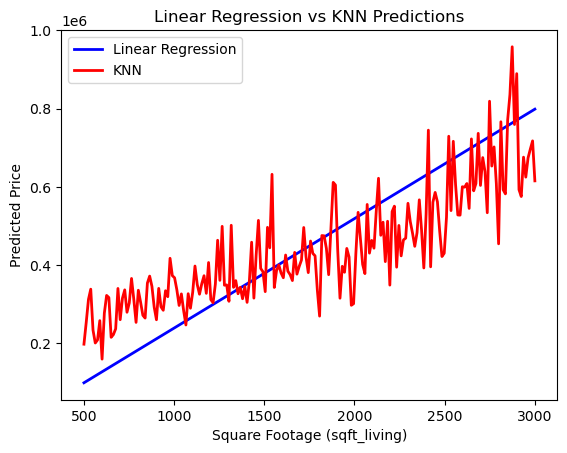

In [89]:
plt.plot(sqft_array, lr_preds, label='Linear Regression', color='blue', linewidth=2)
plt.plot(sqft_array, knn_preds, label='KNN', color='red', linewidth=2)

plt.xlabel('Square Footage (sqft_living)')
plt.ylabel('Predicted Price')
plt.title('Linear Regression vs KNN Predictions')
plt.legend()
plt.show()

11. Finally, let's see what happens when we add another variable. Create a new linear regression model which uses both the square footage of living space and whether or not it is waterfront. When you do this, make sure that you're using the same train and test split by using the same random_state as above. By how much does this improve the model's fit?

In [40]:
X_multi = house_data[['sqft_living', 'waterfront']]
y = house_data['price']


In [41]:
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y, train_size=0.7, test_size=0.3, random_state=100)

In [43]:
# Train new linear regression model
lr_multi = LinearRegression()
lr_multi = lr_multi.fit(X_train_multi, y_train_multi)
# Generate predictions
y_pred_multi = lr_multi.predict(X_test_multi)


In [46]:
#compare RMSE
multi_rmse = root_mean_squared_error(y_test_multi, y_pred_multi)
rmse = root_mean_squared_error(y_test, y_pred)
print(f'multi_RMSE: {multi_rmse: .2f} , RMSE : {rmse: .2f}')

multi_RMSE:  254351.12 , RMSE :  259039.12


In [ ]:
print(f' multi_rmse: {root_mean_squared_error(y_test_multi, y_pred_multi)}')
print(f' multi_mse: {mean_squared_error(y_test_multi, y_pred_multi)}')
print(f' multi_mae: {mean_absolute_error(y_test_multi, y_pred_multi)}')
print(f' multi_mape: {mean_absolute_percentage_error(y_test_multi, y_pred_multi)}')
print(f' multi_r2: {r2_score(y_test_multi, y_pred_multi)}')